# 07 · Neural networks and algorithms from scratch (Step 8)

**Goal:** two parts.

- **A. From scratch:** seven classic algorithms written in NumPy (`src/creditrisk/scratch/`), each checked against scikit-learn on the same data: logistic regression (L2 = MAP) and its Bayesian (Laplace) version, Gaussian Naive Bayes, PCA, Fisher LDA, K-means++, GMM with EM, and a 1-hidden-layer MLP with a gradient check.
- **B. PyTorch MLP:** a deeper network with embeddings for the text columns, through the same 5-fold CV as every other model, compared with the tuned LightGBM from Step 7.

**Data for Part A:** 20,000 training rows (from folds 2–5) and 10,000 check rows (from fold 1),
prepared with the same linear preprocessing as logistic regression. Part B uses the full train split.

**Time:** Part A takes 1–2 minutes; Part B about 10 minutes (needs PyTorch, see the Part B cell).
Part B's predictions are saved, so a re-run loads them.

**Saved results:**

- `reports/results_step8_scratch_vs_sklearn.csv`, `reports/results_step8_mlp.csv`
- `reports/figures/fig18_scratch_checks.png`, `reports/figures/fig19_mlp_training.png`
- MLflow (`make mlflow`)

In [1]:
%load_ext autoreload
%autoreload 2

import glob
import os
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import adjusted_rand_score, roc_auc_score
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from creditrisk.config import PROJECT_ROOT, get_path, set_seed
from creditrisk.data.split import load_splits
from creditrisk.evaluation.bootstrap import paired_bootstrap
from creditrisk.evaluation.cv import load_result, results_table, run_or_load
from creditrisk.evaluation.metrics import evaluate
from creditrisk.features.build import load_features
from creditrisk.models.baselines import default_threads
from creditrisk.models.data import column_groups, get_xy
from creditrisk.models.preprocess import make_linear_preprocessor
from creditrisk.scratch.gmm import GaussianMixtureScratch
from creditrisk.scratch.kmeans import KMeansScratch, plus_plus_seeds
from creditrisk.scratch.lda import FisherLDA
from creditrisk.scratch.logreg import BayesianLogisticRegressionScratch, LogisticRegressionScratch
from creditrisk.scratch.mlp import MLPScratch
from creditrisk.scratch.naive_bayes import GaussianNBScratch
from creditrisk.scratch.pca import PCAScratch

warnings.filterwarnings("ignore", category=ConvergenceWarning)
SEED = set_seed()
FIG = get_path("figures")
REPORTS = PROJECT_ROOT / "reports"
facts = {}

features = load_features()
splits = load_splits()
X, y, folds, ids = get_xy(features, splits, "train")
yv = np.asarray(y)
groups = column_groups(X)
print(f"train split: {X.shape[0]:,} rows x {X.shape[1]} features | threads: {default_threads()}")

train split: 184,503 rows x 240 features | threads: 8


## A. Seven algorithms from scratch vs scikit-learn

Each algorithm is fitted on the same 20,000 rows by our NumPy code and by scikit-learn, then
compared on the 10,000 check rows. The **check** column shows how closely they agree; tiny
numbers (like 1e-07) mean the two give the same answer up to rounding.

Two details:

- **Fisher LDA** and the two clustering methods run on the **PCA components**, not on all
  columns. The full matrix contains exact copies (every one-hot group adds up to 1), which
  makes the within-class scatter matrix singular, so the Fisher direction would not be unique.
- **K-means and the GMM** start from different random points in the two libraries, so they
  can end in slightly different local optima. K-means is therefore also run from the
  **same** starting centres, where the answers must match exactly.

In [2]:
rng = np.random.default_rng(SEED)
fit_pool, check_pool = np.flatnonzero(folds != 1), np.flatnonzero(folds == 1)
fit_rows = np.sort(rng.choice(fit_pool, size=min(20_000, len(fit_pool)), replace=False))
check_rows = np.sort(rng.choice(check_pool, size=min(10_000, len(check_pool)), replace=False))
prep = make_linear_preprocessor(groups["numeric"], groups["cat_low"], groups["cat_high"], seed=SEED)
A_fit = prep.fit_transform(X.iloc[fit_rows], yv[fit_rows])
A_check = prep.transform(X.iloc[check_rows])
y_fit, y_check = yv[fit_rows], yv[check_rows]
print(f"fit rows {A_fit.shape}, check rows {A_check.shape}, default rate {y_fit.mean():.2%}")

rows = []


def timed(make):
    start = time.perf_counter()
    result = make()
    return result, time.perf_counter() - start


def add(algorithm, reference, measure, ours, theirs, check, t_ours, t_theirs):
    rows.append({"algorithm": algorithm, "reference": reference, "measure": measure,
                 "scratch": round(float(ours), 4), "reference value": round(float(theirs), 4),
                 "check": check, "scratch s": round(t_ours, 2), "reference s": round(t_theirs, 2)})


def auc(model, data):
    return roc_auc_score(y_check, model.predict_proba(data)[:, 1])


# 1. Logistic regression, L2 = MAP (Newton's method vs scikit-learn's lbfgs)
C = 0.1
lr_ours, t1 = timed(lambda: LogisticRegressionScratch(C=C).fit(A_fit, y_fit))
lr_ref, t2 = timed(lambda: LogisticRegression(C=C, tol=1e-10, max_iter=5000).fit(A_fit, y_fit))
add("Logistic regression (L2 = MAP)", "sklearn LogisticRegression", "ROC-AUC",
    auc(lr_ours, A_check), auc(lr_ref, A_check),
    f"max |Δ coefficient| = {np.max(np.abs(lr_ours.coef_ - lr_ref.coef_[0])):.1e}; "
    f"Newton steps = {lr_ours.n_iter_}", t1, t2)

# 2. Bayesian logistic regression (Laplace approximation)
blr, t1 = timed(lambda: BayesianLogisticRegressionScratch(C=C).fit(A_fit, y_fit))
p_map, p_bayes = blr.predict_proba_map(A_check)[:, 1], blr.predict_proba(A_check)[:, 1]
monte_carlo = blr.sample_proba(A_check[:2000], n_samples=4000, seed=SEED)
probit_gap = np.max(np.abs(p_bayes[:2000] - monte_carlo))
sigma = blr.logit_std(A_check)
add("Bayesian logistic (Laplace)", "MAP probabilities (same model)", "ROC-AUC",
    roc_auc_score(y_check, p_bayes), roc_auc_score(y_check, p_map),
    f"probit vs Monte Carlo: max |Δp| = {probit_gap:.1e}", t1, 0.0)

# 3. Gaussian Naive Bayes
nb_ours, t1 = timed(lambda: GaussianNBScratch().fit(A_fit, y_fit))
nb_ref, t2 = timed(lambda: GaussianNB().fit(A_fit, y_fit))
gap = np.max(np.abs(nb_ours.predict_proba(A_check) - nb_ref.predict_proba(A_check)))
jll_ours, jll_ref = nb_ours.joint_log_likelihood(A_check), nb_ref.predict_joint_log_proba(A_check)
# rank by log-odds: NB probabilities are often exactly 0 or 1, and ties would blur the AUC
add("Gaussian Naive Bayes", "sklearn GaussianNB", "ROC-AUC (from log-odds)",
    roc_auc_score(y_check, jll_ours[:, 1] - jll_ours[:, 0]),
    roc_auc_score(y_check, jll_ref[:, 1] - jll_ref[:, 0]),
    f"max |Δ probability| = {gap:.1e}", t1, t2)

# 4. PCA via SVD (30 components)
pca_ours, t1 = timed(lambda: PCAScratch(30).fit(A_fit))
pca_ref, t2 = timed(lambda: PCA(30, svd_solver="full").fit(A_fit))
signs = np.sign(np.sum(pca_ours.components_ * pca_ref.components_, axis=1))
gap = np.max(np.abs(pca_ours.components_ - pca_ref.components_ * signs[:, None]))
add("PCA via SVD", "sklearn PCA", "variance explained by 30 components",
    pca_ours.explained_variance_ratio_.sum(), pca_ref.explained_variance_ratio_.sum(),
    f"max |Δ component| (up to sign) = {gap:.1e}", t1, t2)
Z_fit, Z_check = pca_ours.transform(A_fit), pca_ours.transform(A_check)

# 5. Fisher LDA (on the 30 components)
lda_ours, t1 = timed(lambda: FisherLDA().fit(Z_fit, y_fit))
lda_ref, t2 = timed(lambda: LinearDiscriminantAnalysis(solver="lsqr").fit(Z_fit, y_fit))
lda_eig = LinearDiscriminantAnalysis(solver="eigen").fit(Z_fit, y_fit)
corr = abs(np.corrcoef(lda_ours.transform(Z_check)[:, 0], lda_eig.transform(Z_check)[:, 0])[0, 1])
gap = np.max(np.abs(lda_ours.predict_proba(Z_check) - lda_ref.predict_proba(Z_check)))
add("Fisher LDA", "sklearn LinearDiscriminantAnalysis", "ROC-AUC (30 PCA components)",
    auc(lda_ours, Z_check), auc(lda_ref, Z_check),
    f"max |Δ probability| = {gap:.1e}; |corr| of projections = {corr:.6f}", t1, t2)

# 6. K-means++ (10 components, k = 6)
Z10 = Z_fit[:, :10]
km_ours, t1 = timed(lambda: KMeansScratch(6, n_init=4, random_state=SEED).fit(Z10))
km_ref, t2 = timed(lambda: KMeans(6, n_init=4, random_state=SEED).fit(Z10))
start = plus_plus_seeds(Z10, 6, np.random.default_rng(SEED))
same_ours = KMeansScratch(6).fit(Z10, init=start)
same_ref = KMeans(6, init=start, n_init=1, algorithm="lloyd").fit(Z10)
same_ari = adjusted_rand_score(same_ours.labels_, same_ref.labels_)
add("K-means++", "sklearn KMeans", "inertia (10 components, k = 6)", km_ours.inertia_,
    km_ref.inertia_, f"same start: labels agree, ARI = {same_ari:.4f}", t1, t2)

# 7. GMM with EM (10 components, k = 4, best of 3 starts on both sides)
gmm_ours, t1 = timed(lambda: GaussianMixtureScratch(4, n_init=3, random_state=SEED).fit(Z10))
gmm_ref, t2 = timed(lambda: GaussianMixture(4, n_init=3, random_state=SEED).fit(Z10))
history = np.asarray(gmm_ours.log_likelihood_history_)
monotone = bool(np.all(np.diff(history) >= -1e-9))
# same start for both (from one K-means solution): the answers must then agree
start_labels = KMeansScratch(4, random_state=SEED).fit(Z10).labels_
resp0 = np.eye(4)[start_labels]
w0, m0 = resp0.mean(axis=0), resp0.T @ Z10 / resp0.sum(axis=0)[:, None]
c0 = np.array([np.cov(Z10[start_labels == k].T, bias=True) + 1e-6 * np.eye(Z10.shape[1])
               for k in range(4)])
same_gmm_ours = GaussianMixtureScratch(4, tol=1e-8, max_iter=1000).fit(
    Z10, weights_init=w0, means_init=m0, covariances_init=c0)
same_gmm_ref = GaussianMixture(4, tol=1e-8, max_iter=1000, weights_init=w0, means_init=m0,
                               precisions_init=np.linalg.inv(c0)).fit(Z10)
same_gmm_gap = abs(same_gmm_ours.score(Z10) - same_gmm_ref.score(Z10))
add("GMM with EM", "sklearn GaussianMixture", "avg log-likelihood (10 components, k = 4)",
    gmm_ours.score(Z10), gmm_ref.score(Z10),
    f"EM never went down: {monotone} ({len(history)} rounds); "
    f"same start: |Δ log-likelihood| = {same_gmm_gap:.1e}", t1, t2)

# 8. MLP with one hidden layer: same size, optimiser, batch and 30 epochs on both sides
mlp_ours, t1 = timed(lambda: MLPScratch(hidden=32, max_epochs=30, valid_fraction=0.0,
                                        random_state=SEED).fit(A_fit, y_fit))
mlp_ref, t2 = timed(lambda: MLPClassifier((32,), activation="tanh", alpha=1e-4, batch_size=256,
                                          max_iter=30, tol=0.0, n_iter_no_change=1000,
                                          random_state=SEED).fit(A_fit, y_fit))
grad_error = MLPScratch(hidden=5, alpha=1e-2).gradient_check(A_fit[:50, :10], y_fit[:50])
add("MLP, 1 hidden layer (32 units)", "sklearn MLPClassifier", "ROC-AUC",
    auc(mlp_ours, A_check), auc(mlp_ref, A_check),
    f"gradient check: max relative error = {grad_error:.1e}", t1, t2)

scratch_table = pd.DataFrame(rows).set_index("algorithm")
scratch_table.to_csv(REPORTS / "results_step8_scratch_vs_sklearn.csv")
with pd.option_context("display.max_colwidth", 90):
    display(scratch_table)

facts["scratch_vs_sklearn"] = {r["algorithm"]: (r["scratch"], r["reference value"]) for r in rows}
facts["logreg_max_coef_gap"] = float(f"{np.max(np.abs(lr_ours.coef_ - lr_ref.coef_[0])):.1e}")
facts["laplace_probit_vs_mc"] = float(f"{probit_gap:.1e}")
facts["kmeans_same_start_ari"] = round(float(same_ari), 4)
facts["gmm_em_monotone"] = (monotone, len(history))
facts["gmm_same_start_gap"] = float(f"{same_gmm_gap:.1e}")
facts["mlp_gradient_check"] = float(f"{grad_error:.1e}")

fit rows (20000, 441), check rows (10000, 441), default rate 8.22%


,reference,measure,scratch,reference value,check,scratch s,reference s
algorithm,,,,,,,
Logistic regression (L2 = MAP),sklearn LogisticRegression,ROC-AUC,7.544000e-01,7.544000e-01,max |Δ coefficient| = 1.7e-05; Newton steps = 10,25.19,53.48
Bayesian logistic (Laplace),MAP probabilities (same model),ROC-AUC,7.551000e-01,7.544000e-01,probit vs Monte Carlo: max |Δp| = 1.5e-02,23.51,0.00
Gaussian Naive Bayes,sklearn GaussianNB,ROC-AUC (from log-odds),6.614000e-01,6.614000e-01,max |Δ probability| = 1.1e-13,0.12,0.11
PCA via SVD,sklearn PCA,variance explained by 30 components,6.567000e-01,6.567000e-01,max |Δ component| (up to sign) = 4.7e-14,25.01,21.06
Fisher LDA,sklearn LinearDiscriminantAnalysis,ROC-AUC (30 PCA components),7.531000e-01,7.531000e-01,max |Δ probability| = 1.4e-15; |corr| of projections = 1.000000,0.02,0.02
K-means++,sklearn KMeans,"inertia (10 components, k = 6)",1.466934e+06,1.466932e+06,"same start: labels agree, ARI = 1.0000",0.20,0.51
GMM with EM,sklearn GaussianMixture,"avg log-likelihood (10 components, k = 4)",-2.084730e+01,-2.085130e+01,EM never went down: True (50 rounds); same start: |Δ log-likelihood| = 0.0e+00,2.10,1.34
"MLP, 1 hidden layer (32 units)",sklearn MLPClassifier,ROC-AUC,7.053000e-01,7.038000e-01,gradient check: max relative error = 2.0e-07,6.31,58.84


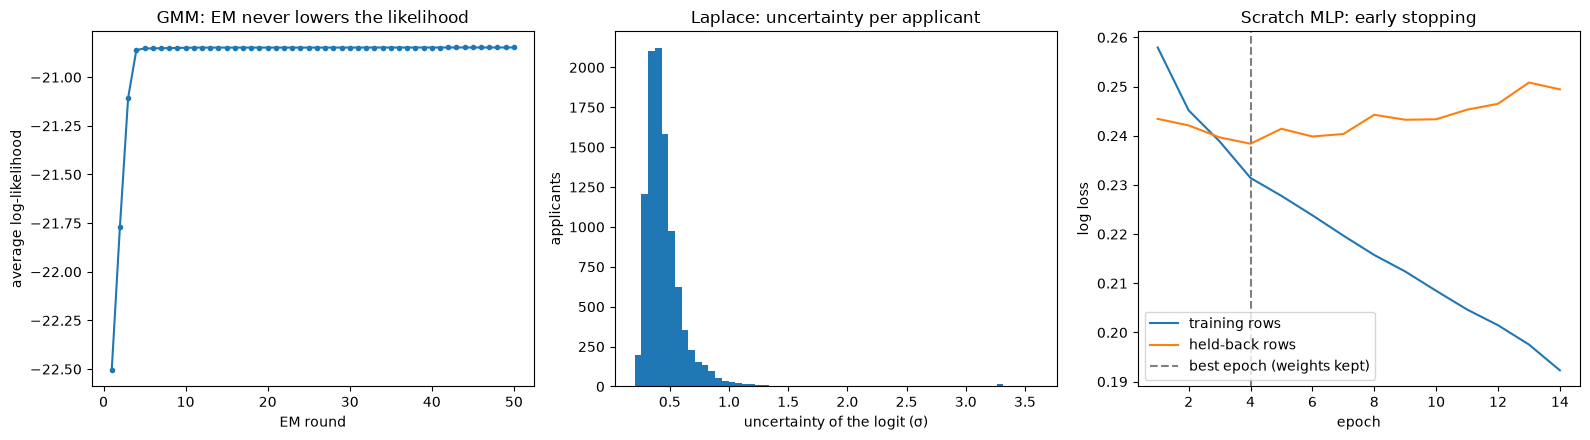

Laplace σ: median 0.412, top 10% from 0.627
default rate: 10% most uncertain 6.40% | the rest 8.46%


In [3]:
mlp_curve = MLPScratch(hidden=32, random_state=SEED).fit(A_fit, y_fit)  # with early stopping
curve = pd.DataFrame(mlp_curve.history_)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
axes[0].plot(np.arange(1, len(history) + 1), history, marker=".")
axes[0].set(xlabel="EM round", ylabel="average log-likelihood",
            title="GMM: EM never lowers the likelihood")
axes[1].hist(sigma, bins=60)
axes[1].set(xlabel="uncertainty of the logit (σ)", ylabel="applicants",
            title="Laplace: uncertainty per applicant")
axes[2].plot(curve["epoch"], curve["train_loss"], label="training rows")
axes[2].plot(curve["epoch"], curve["valid_loss"], label="held-back rows")
axes[2].axvline(curve["valid_loss"].idxmin() + 1, color="grey", linestyle="--",
                label="best epoch (weights kept)")
axes[2].set(xlabel="epoch", ylabel="log loss", title="Scratch MLP: early stopping")
axes[2].legend()
fig.tight_layout()
fig.savefig(FIG / "fig18_scratch_checks.png", dpi=150)
plt.show()

top = sigma >= np.quantile(sigma, 0.9)
print(f"Laplace σ: median {np.median(sigma):.3f}, top 10% from {np.quantile(sigma, 0.9):.3f}")
print(f"default rate: 10% most uncertain {y_check[top].mean():.2%} | "
      f"the rest {y_check[~top].mean():.2%}")
facts["laplace_sigma_median_p90"] = (round(float(np.median(sigma)), 3),
                                     round(float(np.quantile(sigma, 0.9)), 3))
facts["default_rate_uncertain_vs_rest"] = (round(float(y_check[top].mean()), 4),
                                           round(float(y_check[~top].mean()), 4))
facts["scratch_mlp_best_epoch"] = int(curve["valid_loss"].idxmin()) + 1

## B. PyTorch MLP with embeddings

A deeper network for the full data: numbers are clipped, filled and scaled; each text column
gets an **embedding** (a small learned vector per category); then two hidden layers
(256 and 128 units, BatchNorm, ReLU, 30% dropout) and one output. Adam, mini-batches of 1,024,
and early stopping on 10% of each training fold. It runs through the **same 5-fold CV runner**
as every other model, so its score is directly comparable.

**What to expect:** on tabular data like this, gradient-boosted trees usually beat neural
networks (Grinsztajn, Oyallon & Varoquaux, NeurIPS 2022). Their three reasons:

- trees handle **irregular** patterns (sharp jumps, thresholds), while networks prefer smooth functions;
- trees **ignore useless features** easily, while networks are hurt by them;
- trees work feature by feature, while networks mix all features together (they are
  "rotation invariant"), which loses the meaning of each column.

The last cell also tries a **blend**: the average of the LightGBM and MLP probabilities. If the
two models make different mistakes, the blend can beat both.

**Needs PyTorch.** If it is missing, install the CPU version (about 200 MB), restart the kernel,
and run this part again:

```
pip install torch --index-url https://download.pytorch.org/whl/cpu
```

In [4]:
try:
    import torch

    from creditrisk.models.mlp import TorchMLPClassifier
    HAVE_TORCH = True
    print(f"PyTorch {torch.__version__}, using {default_threads()} threads")
except ImportError:
    HAVE_TORCH = False
    print("PyTorch is not installed, so Part B is skipped. Install the CPU version with:\n"
          "  pip install torch --index-url https://download.pytorch.org/whl/cpu")

PyTorch 2.14.1+cpu, using 8 threads


    epoch  1: train loss 0.3054, check ROC-AUC 0.7608
    epoch  2: train loss 0.2461, check ROC-AUC 0.7677
    epoch  3: train loss 0.2431, check ROC-AUC 0.7668
    epoch  4: train loss 0.2406, check ROC-AUC 0.7676
    epoch  5: train loss 0.2390, check ROC-AUC 0.7656
    epoch  6: train loss 0.2373, check ROC-AUC 0.7656


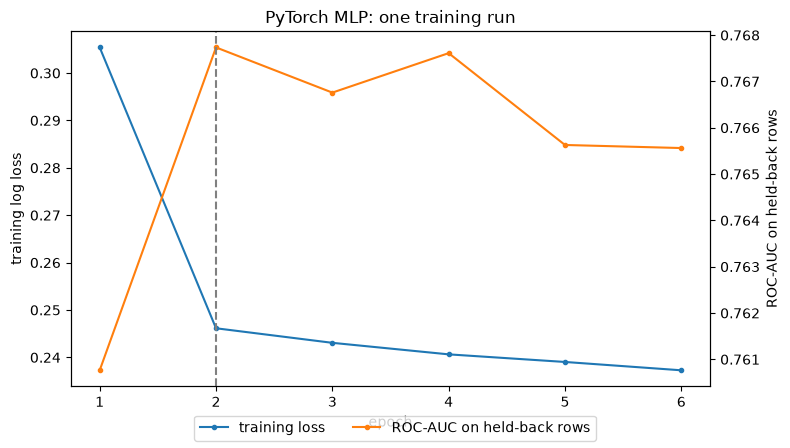

In [5]:
if HAVE_TORCH:
    # one fit on folds 2-5 to see the training curve (each epoch prints a line)
    curve_model = TorchMLPClassifier(seed=SEED, verbose=True)
    curve_model.fit(X.iloc[np.flatnonzero(folds != 1)], yv[folds != 1])
    torch_curve = pd.DataFrame(curve_model.history_)
    fig, ax1 = plt.subplots(figsize=(8, 4.5))
    ax1.plot(torch_curve["epoch"], torch_curve["train_loss"], marker=".", label="training loss")
    ax1.set(xlabel="epoch", ylabel="training log loss", title="PyTorch MLP: one training run")
    ax2 = ax1.twinx()
    ax2.plot(torch_curve["epoch"], torch_curve["check_auc"], marker=".", color="tab:orange",
             label="ROC-AUC on held-back rows")
    ax2.axvline(curve_model.best_epoch_, color="grey", linestyle="--")
    ax2.set_ylabel("ROC-AUC on held-back rows")
    fig.legend(loc="lower center", ncol=2)
    fig.tight_layout()
    fig.savefig(FIG / "fig19_mlp_training.png", dpi=150)
    plt.show()
    facts["torch_best_epoch"] = (curve_model.best_epoch_, len(torch_curve))
    facts["torch_one_fit_minutes"] = round(curve_model.fit_seconds_ / 60, 1)

In [6]:
if HAVE_TORCH:
    mlp = run_or_load(lambda: TorchMLPClassifier(seed=SEED), X, y, folds, "step8_mlp_torch",
                      ids=ids, step=8, verbose=True)
    mlp.name = "mlp_torch"
    pattern = str(get_path("processed") / "oof" / "step7_lightgbm_tuned_*.parquet")
    tuned_files = sorted(glob.glob(pattern), key=os.path.getmtime)
    lgbm = load_result(os.path.basename(tuned_files[-1])[:-len(".parquet")], ids=ids,
                       display_name="lightgbm_tuned")
    blend_p = (lgbm.oof + mlp.oof) / 2
    blend_auc = evaluate(yv, blend_p)["roc_auc"]
    lgbm_vs_mlp = paired_bootstrap(yv, lgbm.oof, mlp.oof)
    blend_vs_lgbm = paired_bootstrap(yv, blend_p, lgbm.oof)

    table = results_table([lgbm, mlp])
    table.to_csv(REPORTS / "results_step8_mlp.csv")
    display(table)
    print(f"LightGBM - MLP: {lgbm_vs_mlp['difference']:+.4f} "
          f"(95% CI {lgbm_vs_mlp['low']:+.4f} to {lgbm_vs_mlp['high']:+.4f}), "
          f"significant: {lgbm_vs_mlp['significant']}")
    print(f"blend (average of the two): ROC-AUC {blend_auc:.4f}; blend - LightGBM: "
          f"{blend_vs_lgbm['difference']:+.4f} (95% CI {blend_vs_lgbm['low']:+.4f} to "
          f"{blend_vs_lgbm['high']:+.4f}), significant: {blend_vs_lgbm['significant']}")
    print(f"correlation of the two models' predictions: {np.corrcoef(lgbm.oof, mlp.oof)[0, 1]:.3f}")

    s = mlp.summary
    facts["mlp_torch_cv"] = (round(s["roc_auc"], 4), round(s["roc_auc_low"], 4),
                             round(s["roc_auc_high"], 4))
    facts["mlp_torch_brier_ece"] = (round(s["brier"], 4), round(s["ece"], 4))
    facts["lightgbm_tuned_cv"] = round(lgbm.summary["roc_auc"], 4)
    facts["lgbm_minus_mlp"] = (round(lgbm_vs_mlp["difference"], 4), lgbm_vs_mlp["significant"])
    facts["blend_auc"] = round(float(blend_auc), 4)
    facts["blend_minus_lgbm"] = (round(blend_vs_lgbm["difference"], 4),
                                 blend_vs_lgbm["significant"])
    facts["prediction_correlation"] = round(float(np.corrcoef(lgbm.oof, mlp.oof)[0, 1]), 3)
    facts["mlp_cv_minutes"] = round(s["seconds"] / 60, 1) if s["seconds"] == s["seconds"] else None

  step8_mlp_torch: fold 1 done, ROC-AUC 0.7724 (15s so far)
  step8_mlp_torch: fold 2 done, ROC-AUC 0.7743 (34s so far)
  step8_mlp_torch: fold 3 done, ROC-AUC 0.7671 (53s so far)
  step8_mlp_torch: fold 4 done, ROC-AUC 0.7695 (75s so far)
  step8_mlp_torch: fold 5 done, ROC-AUC 0.7784 (94s so far)


,ROC-AUC,95% CI,fold mean ± std,PR-AUC,KS,Brier,ECE,seconds
model,,,,,,,,
lightgbm_tuned,0.7899,0.7865 to 0.7930,0.7899 ± 0.0052,0.2791,0.4386,0.0659,0.0020,NaN
mlp_torch,0.7718,0.7682 to 0.7752,0.7724 ± 0.0044,0.2522,0.4056,0.0673,0.0059,93.8


LightGBM - MLP: +0.0181 (95% CI +0.0163 to +0.0199), significant: True
blend (average of the two): ROC-AUC 0.7859; blend - LightGBM: -0.0040 (95% CI -0.0049 to -0.0031), significant: True
correlation of the two models' predictions: 0.887


## Key facts
Send these to Claude to get the filled-in Findings.

In [7]:
for key, value in facts.items():
    print(f"{key:<32} {value}")

scratch_vs_sklearn               {'Logistic regression (L2 = MAP)': (0.7544, 0.7544), 'Bayesian logistic (Laplace)': (0.7551, 0.7544), 'Gaussian Naive Bayes': (0.6614, 0.6614), 'PCA via SVD': (0.6567, 0.6567), 'Fisher LDA': (0.7531, 0.7531), 'K-means++': (1466933.9109, 1466931.8721), 'GMM with EM': (-20.8473, -20.8513), 'MLP, 1 hidden layer (32 units)': (0.7053, 0.7038)}
logreg_max_coef_gap              1.7e-05
laplace_probit_vs_mc             0.015
kmeans_same_start_ari            1.0
gmm_em_monotone                  (True, 50)
gmm_same_start_gap               0.0
mlp_gradient_check               2e-07
laplace_sigma_median_p90         (0.412, 0.627)
default_rate_uncertain_vs_rest   (0.064, 0.0846)
scratch_mlp_best_epoch           4
torch_best_epoch                 (2, 6)
torch_one_fit_minutes            0.3
mlp_torch_cv                     (0.7718, 0.7682, 0.7752)
mlp_torch_brier_ece              (0.0673, 0.0059)
lightgbm_tuned_cv                0.7899
lgbm_minus_mlp                  

## Findings

- **From scratch vs scikit-learn (20,000 training rows, 10,000 check rows):**
  - logistic regression (L2 = MAP, Newton's method): ROC-AUC 0.7544 vs 0.7544; largest coefficient gap 1.7e-05, after __ Newton steps;
  - Gaussian Naive Bayes: 0.6614 vs 0.6614 (ranked by log-odds); largest probability gap __;
  - PCA: 30 components explain 65.7% of the variance in both; largest component gap __ (up to sign);
  - Fisher LDA (on 30 components): ROC-AUC 0.7531 vs 0.7531; projection correlation __;
  - K-means++ (k = 6): inertia 1,466,934 vs 1,466,932 (a 0.0001% difference); from the same start the labels agree exactly (ARI 1.0);
  - GMM with EM (k = 4, best of 3 starts): average log-likelihood −20.847 vs −20.851; EM never lowered the likelihood over 50 rounds; from the same start the two agree exactly (gap 0.0);
  - MLP with one hidden layer: ROC-AUC 0.7053 vs 0.7038; gradient check error 2e-07. With early stopping, its best epoch was 4, so on 20,000 rows it overfits quickly, which is why it scores below logistic regression here.
- **Bayesian logistic regression (Laplace):** ROC-AUC 0.7551, almost the same as MAP (0.7544). The probit approximation matches Monte Carlo within 0.015. The median uncertainty σ is 0.41 (the top 10% are above 0.63). The 10% most uncertain applicants default at 6.4% vs 8.5% for the rest. So uncertainty is not the same as risk: it marks applicants who are unusual for the model, not applicants who are likely to default.
- **PyTorch MLP (5-fold CV):** ROC-AUC 0.7718 (95% CI 0.7682 to 0.7752) vs 0.7899 for tuned LightGBM, a gap of 0.0181 (significant), as Grinsztajn et al. (2022) predict for tabular data. It is even slightly below logistic regression (0.776 in Step 6). Its best epoch was 2 of 6, so the network starts to overfit almost at once. Its probabilities are well calibrated (Brier 0.067, ECE 0.006), and the full 5-fold run took 1.6 minutes.
- **Blend:** the average of LightGBM and the MLP scores 0.7859, a change of −0.0040 vs LightGBM alone (significant). The two models' predictions correlate at 0.887, so the MLP makes mostly the same mistakes while being weaker, and averaging only dilutes LightGBM. The final model stays LightGBM alone.
- **Correction to Step 6:** in 5-fold CV, raw Naive Bayes scores 0.5432 from its probabilities but 0.6638 from its log-odds. 82.3% of applicants get a probability of exactly 1.0: their real scores differ, but the computer rounds probabilities that close to 1 to exactly 1.0, so they become ties. Only NB is affected this way, because its underlying score is continuous; the tree and KNN give coarse scores by design. Lesson for the evaluation: when a model's probabilities saturate, compute ROC-AUC from a continuous score such as the log-odds.

In [8]:
from sklearn.metrics import roc_auc_score

from creditrisk.models import baselines

log_odds, probs = np.full(len(yv), np.nan), np.full(len(yv), np.nan)
for k in np.unique(folds):
    fit, held = folds != k, folds == k
    model = baselines.naive_bayes(groups, seed=SEED).fit(X[fit], yv[fit])
    jll = model[-1].predict_joint_log_proba(model[:-1].transform(X[held]))  # same preprocessing as Step 6
    log_odds[held] = jll[:, 1] - jll[:, 0]
    probs[held] = model.predict_proba(X[held])[:, 1]
print(f"raw Naive Bayes, 5-fold CV: ROC-AUC {roc_auc_score(yv, probs):.4f} from probabilities, "
      f"{roc_auc_score(yv, log_odds):.4f} from log-odds")
print(f"applicants with a probability of exactly 1.0: {np.mean(probs == 1.0):.1%}")

raw Naive Bayes, 5-fold CV: ROC-AUC 0.5432 from probabilities, 0.6638 from log-odds
applicants with a probability of exactly 1.0: 82.3%
